In [22]:
# compare the fr (stim total, on, sus vs trial numbers)
# compare stim vs base fr for each padxsync - paired t
# 2026-04-19 no star for sig

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline

matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['pdf.fonttype'] = 42 # enables editing of strings of characters rather than individual characters
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = 'Arial'

In [24]:
dir = os.getcwd()
base_dir = os.path.dirname(dir)
data_dir = os.path.join(base_dir, 'data')

In [25]:
male_list = ['BRC2','BRC5','BRN5','BTT1','BTT3','BPO5','BPU4','BQD3','BTK4','BTM2','BTM3']
female_list = ['BQQ4','BRD2','BRO3','BRO4','BUF4','BPP1','BPV4','BPV5','BQE3','BTN4','BTR5']

sex_map = {name: 'Male' for name in male_list}
sex_map.update({name: 'Female' for name in female_list})

In [26]:
npads_df_FP_file = os.path.join(data_dir,'npads_df_FP.csv')
npads_df_HP_file = os.path.join(data_dir,'npads_df_HP.csv')
npads_df_mice_FP_file = os.path.join(data_dir,'npads_df_mice_FP.csv')
npads_df_mice_HP_file = os.path.join(data_dir,'npads_df_mice_HP.csv')
npads_df_FP = pd.read_csv(npads_df_FP_file)
npads_df_HP = pd.read_csv(npads_df_HP_file)
npads_df_mice_FP = pd.read_csv(npads_df_mice_FP_file)
npads_df_mice_HP = pd.read_csv(npads_df_mice_HP_file)

C:\Users\ajemanu\AppData\Local\Temp\ipykernel_18980\969167775.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mice_TrkC['sex'] = df_mice_TrkC['animalID'].map(sex_map)
C:\Users\ajemanu\AppData\Local\Temp\ipykernel_18980\969167775.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mice_TrkB['sex'] = df_mice_TrkB['animalID'].map(sex_map)


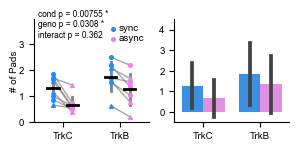

In [27]:
# bar plot - sync vs async x genotype - FP

group1 = 'TrkC'
group2 = 'TrkB'
npads_df = npads_df_FP.copy()
df_mice = npads_df_mice_FP 
order_x = ['TrkC','TrkB']

plot_var = ['npads'] # variables to plot
sync_color = 'dodgerblue'
async_color = 'violet'
line_color = 'grey'
mean_color = 'black'

scatter_size = 2
alpha_scatter = 0.2
alpha_sd = 0.7

markersize = 7
mwidth = 0.3 # half of the mean bar

star_size = 8
pval_size = 6 # text size for pval
star_font = 'Consolas'
mark_male = '^'
mark_female = 'o'
mark_map = {'Male':'^', 'Female':'o'}

zorder_line = 1
zorder_dots = 7
zorder_mean = 15

f, ax = plt.subplots(1,2, figsize=[3,1.5])
# f, ax = plt.subplots(1,2, figsize=[6,3])

# box plots of units
colorpal = {'sync':sync_color, 'async':async_color}
colorpal2 = {'sync':'#555555', 'async':'#555555'}
hue_order_cond = ['sync','async']
# sns.violinplot(ax=ax[1],x='genoGroup', y='npads', hue='cond', data=npads_df, 
#                order = order_x,hue_order=hue_order_cond, width=0.75,
#                inner=None,density_norm='width', bw_adjust =1.5,palette = colorpal)

sns.barplot(ax=ax[1],x='genoGroup', y='npads', hue='cond', data=npads_df,
            estimator='mean',errorbar='sd', order = order_x,hue_order=hue_order_cond, 
            width=0.75, palette = colorpal)

# average by animals
x_plot = np.array([1,2,4,5]) # x value for TrkC-sync, TrkC-async, TrkB-sync, TrkB-async
df_mice_TrkC = df_mice[df_mice['genoGroup'].isin(['TrkC','TrkC_S1HP'])]
df_mice_TrkB = df_mice[df_mice['genoGroup'].isin(['TrkB','TrkB_S1HP'])]

df_mice_TrkC['sex'] = df_mice_TrkC['animalID'].map(sex_map)
df_mice_TrkB['sex'] = df_mice_TrkB['animalID'].map(sex_map)

df_mice_TrkC_sync = df_mice_TrkC[df_mice_TrkC['cond']=='sync']
df_mice_TrkB_sync = df_mice_TrkB[df_mice_TrkB['cond']=='sync']

females_TrkC = np.where(df_mice_TrkC_sync['sex'] == 'Female')[0] # idx of which are females
males_TrkC = np.where(df_mice_TrkC_sync['sex'] == 'Male')[0]
females_TrkB = np.where(df_mice_TrkB_sync['sex'] == 'Female')[0]
males_TrkB = np.where(df_mice_TrkB_sync['sex'] == 'Male')[0]

sync_TrkC_array = np.array(df_mice_TrkC[df_mice_TrkC['cond']=='sync']['npads'])
async_TrkC_array = np.array(df_mice_TrkC[df_mice_TrkC['cond']=='async']['npads'])
sync_TrkB_array = np.array(df_mice_TrkB[df_mice_TrkB['cond']=='sync']['npads'])
async_TrkB_array = np.array(df_mice_TrkB[df_mice_TrkB['cond']=='async']['npads'])

n_TrkC = len(sync_TrkC_array) # number of animals per geno
n_TrkB = len(sync_TrkB_array)

x1_TrkC_array = np.repeat(x_plot[0], n_TrkC)
x2_TrkC_array = np.repeat(x_plot[1], n_TrkC)
x1_TrkB_array = np.repeat(x_plot[2], n_TrkB)
x2_TrkB_array = np.repeat(x_plot[3], n_TrkB)

ax[0].plot([x1_TrkC_array,x2_TrkC_array], [sync_TrkC_array,async_TrkC_array],c=line_color,lw=1,alpha=0.7,zorder=zorder_line)
ax[0].plot([x1_TrkB_array,x2_TrkB_array], [sync_TrkB_array,async_TrkB_array],c=line_color,lw=1,alpha=0.7,zorder=zorder_line)

ax[0].scatter(x1_TrkC_array[females_TrkC],sync_TrkC_array[females_TrkC],s=markersize,marker=mark_female,c=sync_color,zorder=zorder_dots,label='sync')
ax[0].scatter(x1_TrkC_array[males_TrkC],sync_TrkC_array[males_TrkC],s=markersize,marker=mark_male,c=sync_color,zorder=zorder_dots)
ax[0].scatter(x2_TrkC_array[females_TrkC],async_TrkC_array[females_TrkC],s=markersize,marker=mark_female,c=async_color,zorder=zorder_dots, label='async')
ax[0].scatter(x2_TrkC_array[males_TrkC],async_TrkC_array[males_TrkC],s=markersize,marker=mark_male,c=async_color,zorder=zorder_dots)
ax[0].scatter(x1_TrkB_array[females_TrkB],sync_TrkB_array[females_TrkB],s=markersize,marker=mark_female,c=sync_color,zorder=zorder_dots)
ax[0].scatter(x1_TrkB_array[males_TrkB],sync_TrkB_array[males_TrkB],s=markersize,marker=mark_male,c=sync_color,zorder=zorder_dots)
ax[0].scatter(x2_TrkB_array[females_TrkB],async_TrkB_array[females_TrkB],s=markersize,marker=mark_female,c=async_color,zorder=zorder_dots)
ax[0].scatter(x2_TrkB_array[males_TrkB],async_TrkB_array[males_TrkB],s=markersize,marker=mark_male,c=async_color,zorder=zorder_dots)

ax[0].plot([x_plot[0]-mwidth,x_plot[0]+mwidth], [np.mean(sync_TrkC_array),np.mean(sync_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
ax[0].plot([x_plot[1]-mwidth,x_plot[1]+mwidth], [np.mean(async_TrkC_array),np.mean(async_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
ax[0].plot([x_plot[2]-mwidth,x_plot[2]+mwidth], [np.mean(sync_TrkB_array),np.mean(sync_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)
ax[0].plot([x_plot[3]-mwidth,x_plot[3]+mwidth], [np.mean(async_TrkB_array),np.mean(async_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)

ax[0].plot([x_plot[0],x_plot[0]], [np.mean(sync_TrkC_array)-np.std(sync_TrkC_array),np.mean(sync_TrkC_array)+np.std(sync_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
ax[0].plot([x_plot[1],x_plot[1]], [np.mean(async_TrkC_array)-np.std(async_TrkC_array),np.mean(async_TrkC_array)+np.std(async_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
ax[0].plot([x_plot[2],x_plot[2]], [np.mean(sync_TrkB_array)-np.std(sync_TrkB_array),np.mean(sync_TrkB_array)+np.std(sync_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)
ax[0].plot([x_plot[3],x_plot[3]], [np.mean(async_TrkB_array)-np.std(async_TrkB_array),np.mean(async_TrkB_array)+np.std(async_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)

# ### add significance
ax[0].text(x=0.2, y=3.25, s='cond p = 0.00755 *\ngeno p = 0.0308 *\ninteract p = 0.362', size=pval_size,ha='left')

ax[1].set_ylabel('', labelpad=0)
ax[0].set_ylabel('# of Pads', labelpad=0)
# 
ax[1].set_ylim([-0.5,4.5])

ax[0].set_xlim([0,6])
ax[0].set_ylim([0,3.95])

ax[0].set_xticks([(x_plot[0]+x_plot[1])/2,(x_plot[2]+x_plot[3])/2])
ax[0].set_xticklabels(['TrkC','TrkB'])
ax[1].set_xticklabels(['TrkC','TrkB'])

ax[1].get_legend().remove()

ax[0].legend(borderpad=0,      # Fractional whitespace inside the legend border
    labelspacing=0.1,   # Vertical space between entries
    handlelength=0.7,   # Length of the legend handles (lines/markers)
    handletextpad=0.2,  # Pad between handle and text
    columnspacing=0.5,  # Spacing between columns (if ncol > 1),
    loc = 'upper right',
    frameon=False)

for i in [0,1]:
    ax[i].set_xlabel('', labelpad=0)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    # ax[0,i].set_aspect('equal',adjustable='datalim')

plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.tight_layout()

plt.show()

C:\Users\ajemanu\AppData\Local\Temp\ipykernel_18980\355267744.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mice_TrkC['sex'] = df_mice_TrkC['animalID'].map(sex_map)
C:\Users\ajemanu\AppData\Local\Temp\ipykernel_18980\355267744.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mice_TrkB['sex'] = df_mice_TrkB['animalID'].map(sex_map)


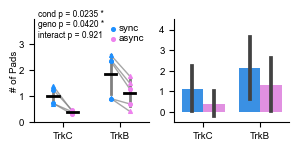

In [28]:
# box plot - sync vs async x genotype - HP

group1 = 'TrkC_S1HP'
group2 = 'TrkB_S1HP'
npads_df = npads_df_HP
df_mice = npads_df_mice_HP 
order_x =  ['TrkC_S1HP','TrkB_S1HP']

plot_var = ['npads'] # variables to plot
sync_color = 'dodgerblue'
async_color = 'violet'
line_color = 'grey'
mean_color = 'black'

scatter_size = 2
alpha_scatter = 0.2
alpha_sd = 0.7

markersize = 7
mwidth = 0.3 # half of the mean bar

star_size = 8
pval_size = 6 # text size for pval
star_font = 'Consolas'
mark_male = '^'
mark_female = 'o'
mark_map = {'Male':'^', 'Female':'o'}

zorder_line = 1
zorder_dots = 7
zorder_mean = 15

f, ax = plt.subplots(1,2, figsize=[3,1.5])

# box plots of units
colorpal = {'sync':sync_color, 'async':async_color}
colorpal2 = {'sync':'#555555', 'async':'#555555'}
hue_order_cond = ['sync','async']
# sns.violinplot(ax=ax[1],x='genoGroup', y='npads', hue='cond', data=npads_df, 
#                order = order_x,hue_order=hue_order_cond, width=0.75,
#                inner=None,density_norm='width', bw_adjust =1.5,palette = colorpal)
sns.barplot(ax=ax[1],x='genoGroup', y='npads', hue='cond', data=npads_df,
            estimator='mean',errorbar='sd', order = order_x,hue_order=hue_order_cond, 
            width=0.75, palette = colorpal)

# average by animals
x_plot = np.array([1,2,4,5]) # x value for TrkC-sync, TrkC-async, TrkB-sync, TrkB-async
df_mice_TrkC = df_mice[df_mice['genoGroup'].isin(['TrkC','TrkC_S1HP'])]
df_mice_TrkB = df_mice[df_mice['genoGroup'].isin(['TrkB','TrkB_S1HP'])]

df_mice_TrkC['sex'] = df_mice_TrkC['animalID'].map(sex_map)
df_mice_TrkB['sex'] = df_mice_TrkB['animalID'].map(sex_map)

df_mice_TrkC_sync = df_mice_TrkC[df_mice_TrkC['cond']=='sync']
df_mice_TrkB_sync = df_mice_TrkB[df_mice_TrkB['cond']=='sync']

females_TrkC = np.where(df_mice_TrkC_sync['sex'] == 'Female')[0] # idx of which are females
males_TrkC = np.where(df_mice_TrkC_sync['sex'] == 'Male')[0]
females_TrkB = np.where(df_mice_TrkB_sync['sex'] == 'Female')[0]
males_TrkB = np.where(df_mice_TrkB_sync['sex'] == 'Male')[0]

sync_TrkC_array = np.array(df_mice_TrkC[df_mice_TrkC['cond']=='sync']['npads'])
async_TrkC_array = np.array(df_mice_TrkC[df_mice_TrkC['cond']=='async']['npads'])
sync_TrkB_array = np.array(df_mice_TrkB[df_mice_TrkB['cond']=='sync']['npads'])
async_TrkB_array = np.array(df_mice_TrkB[df_mice_TrkB['cond']=='async']['npads'])

n_TrkC = len(sync_TrkC_array) # number of animals per geno
n_TrkB = len(sync_TrkB_array)

x1_TrkC_array = np.repeat(x_plot[0], n_TrkC)
x2_TrkC_array = np.repeat(x_plot[1], n_TrkC)
x1_TrkB_array = np.repeat(x_plot[2], n_TrkB)
x2_TrkB_array = np.repeat(x_plot[3], n_TrkB)

ax[0].plot([x1_TrkC_array,x2_TrkC_array], [sync_TrkC_array,async_TrkC_array],c=line_color,lw=1,alpha=0.7,zorder=zorder_line)
ax[0].plot([x1_TrkB_array,x2_TrkB_array], [sync_TrkB_array,async_TrkB_array],c=line_color,lw=1,alpha=0.7,zorder=zorder_line)

ax[0].scatter(x1_TrkC_array[females_TrkC],sync_TrkC_array[females_TrkC],s=markersize,marker=mark_female,c=sync_color,zorder=zorder_dots,label='sync')
ax[0].scatter(x1_TrkC_array[males_TrkC],sync_TrkC_array[males_TrkC],s=markersize,marker=mark_male,c=sync_color,zorder=zorder_dots)
ax[0].scatter(x2_TrkC_array[females_TrkC],async_TrkC_array[females_TrkC],s=markersize,marker=mark_female,c=async_color,zorder=zorder_dots, label='async')
ax[0].scatter(x2_TrkC_array[males_TrkC],async_TrkC_array[males_TrkC],s=markersize,marker=mark_male,c=async_color,zorder=zorder_dots)
ax[0].scatter(x1_TrkB_array[females_TrkB],sync_TrkB_array[females_TrkB],s=markersize,marker=mark_female,c=sync_color,zorder=zorder_dots)
ax[0].scatter(x1_TrkB_array[males_TrkB],sync_TrkB_array[males_TrkB],s=markersize,marker=mark_male,c=sync_color,zorder=zorder_dots)
ax[0].scatter(x2_TrkB_array[females_TrkB],async_TrkB_array[females_TrkB],s=markersize,marker=mark_female,c=async_color,zorder=zorder_dots)
ax[0].scatter(x2_TrkB_array[males_TrkB],async_TrkB_array[males_TrkB],s=markersize,marker=mark_male,c=async_color,zorder=zorder_dots)

ax[0].plot([x_plot[0]-mwidth,x_plot[0]+mwidth], [np.mean(sync_TrkC_array),np.mean(sync_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
ax[0].plot([x_plot[1]-mwidth,x_plot[1]+mwidth], [np.mean(async_TrkC_array),np.mean(async_TrkC_array)],c=mean_color,lw=2,zorder=zorder_mean)
ax[0].plot([x_plot[2]-mwidth,x_plot[2]+mwidth], [np.mean(sync_TrkB_array),np.mean(sync_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)
ax[0].plot([x_plot[3]-mwidth,x_plot[3]+mwidth], [np.mean(async_TrkB_array),np.mean(async_TrkB_array)],c=mean_color,lw=2,zorder=zorder_mean)

ax[0].plot([x_plot[0],x_plot[0]], [np.mean(sync_TrkC_array)-np.std(sync_TrkC_array),np.mean(sync_TrkC_array)+np.std(sync_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
ax[0].plot([x_plot[1],x_plot[1]], [np.mean(async_TrkC_array)-np.std(async_TrkC_array),np.mean(async_TrkC_array)+np.std(async_TrkC_array)],c=line_color,lw=2,zorder=zorder_line)
ax[0].plot([x_plot[2],x_plot[2]], [np.mean(sync_TrkB_array)-np.std(sync_TrkB_array),np.mean(sync_TrkB_array)+np.std(sync_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)
ax[0].plot([x_plot[3],x_plot[3]], [np.mean(async_TrkB_array)-np.std(async_TrkB_array),np.mean(async_TrkB_array)+np.std(async_TrkB_array)],c=line_color,lw=2,zorder=zorder_line)

# ### add significance
ax[0].text(x=0.2, y=3.25, s='cond p = 0.0235 *\ngeno p = 0.0420 *\ninteract p = 0.921', size=pval_size,ha='left')

ax[1].set_ylabel('', labelpad=0)
ax[0].set_ylabel('# of Pads', labelpad=0)
# 
ax[1].set_ylim([-0.5,4.5])

ax[0].set_xlim([0,6])
ax[0].set_ylim([0,3.95])

ax[0].set_xticks([(x_plot[0]+x_plot[1])/2,(x_plot[2]+x_plot[3])/2])
ax[0].set_xticklabels(['TrkC','TrkB'])
ax[1].set_xticklabels(['TrkC','TrkB'])

ax[1].get_legend().remove()

ax[0].legend(borderpad=0,      # Fractional whitespace inside the legend border
    labelspacing=0.1,   # Vertical space between entries
    handlelength=0.7,   # Length of the legend handles (lines/markers)
    handletextpad=0.2,  # Pad between handle and text
    columnspacing=0.5,  # Spacing between columns (if ncol > 1),
    loc = 'upper right',
    frameon=False)

for i in [0,1]:
    ax[i].set_xlabel('', labelpad=0)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.tight_layout()

plt.show()